# Calculate the profit difference between spot market and capture price contracts

Some traders are providing contracts that take into account a profit calculation basing on monthly system capture prices instead of spot market prices. This notebook calculates resulting difference of profits between these two methods.

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Read simulation results

In [56]:
results = pd.read_csv('results.csv', index_col=0)
results.index = pd.to_datetime(results.index)

### Annual capture price

In [57]:
annual_capture_price = 46.24

### Read monthly capture prices

In [58]:
monthly_system_capture_prices = pd.read_csv('2024_monatsmarktwerte.csv', sep=';').T
monthly_system_capture_prices = monthly_system_capture_prices.iloc[:, [7]] # Select only the column with solar capture prices
monthly_system_capture_prices = monthly_system_capture_prices.iloc[1:]
monthly_system_capture_prices.index = pd.date_range(start='2024-01-01', end='2024-12-31', freq='ME')
monthly_system_capture_prices.index = monthly_system_capture_prices.index - pd.offsets.MonthBegin(1)
monthly_system_capture_prices.columns = ['solar_capture_price']
monthly_system_capture_prices.head()

,solar_capture_price
2024-01-01,"7,535"
2024-02-01,"5,875"
2024-03-01,"4,965"
2024-04-01,"3,795"
2024-05-01,"3,161"


# Read DAA prices

In [59]:
import os

print(os.getcwd())

c:\Users\bui\Nextcloud\Tools\PV_Bess_optimizier\Projects\Lalendorf


In [60]:
path = 'data/2024/DA/2024_daa.csv'
daa = pd.read_csv(path, index_col=0)
daa.index = pd.to_datetime(daa.index)
daa.head()

,DAA
2024-01-01 00:00:00,0.10
2024-01-01 00:15:00,0.10
2024-01-01 00:30:00,0.10
2024-01-01 00:45:00,0.10
2024-01-01 01:00:00,0.01


<Axes: >

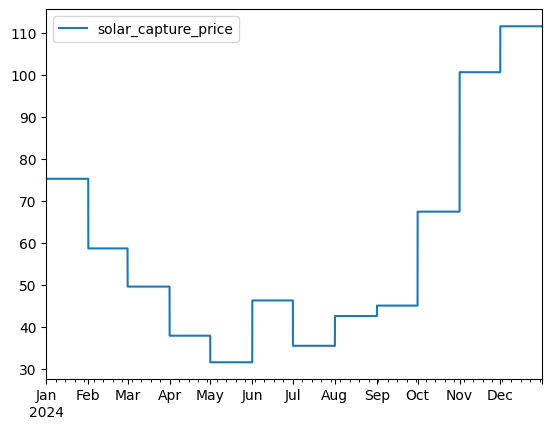

In [61]:

monthly_system_capture_prices_15min = monthly_system_capture_prices.resample('15min').ffill()
monthly_system_capture_prices_15min = monthly_system_capture_prices_15min.reindex(pd.date_range(start='2024-01-01', end='2024-12-31 23:45:00', freq='15min'), method='ffill')
monthly_system_capture_prices_15min['solar_capture_price'] = monthly_system_capture_prices_15min['solar_capture_price'].str.replace(',', '.').astype(float) * 10 # Convert to float and from EUR/kWh to EUR/MWh
monthly_system_capture_prices_15min.plot()

In [62]:
pv_output = results['pv_output']
pv_to_bess = results['p_charge_daa_ida_idc']
pv_direct_feed_in = pv_output - pv_to_bess

### Calculate two szenarios
* Szenario 1: PV direct feed in and PV to BESS sold at DAA spotmarket price
* Szenario 2: PV direct feed in sold at monthly capure price and PV to BESS sold at DAA spotmarket price

### Calculate szenarios

In [63]:
annual_pv_direct_feed_in_profit_spotmarket = (pv_direct_feed_in * daa['DAA']).sum() / 4
condition_daa_positive = results.daa_price >= 0
# annual_pv_production_excl_negative_market_price_hours = results.loc[condition_daa_positive, 'pv_output'].sum() * 15 / 60
annual_pv_direct_feed_in_profit_spotmarket_excluding_negative_daa = (pv_direct_feed_in[condition_daa_positive] * daa['DAA'][condition_daa_positive]).sum() / 4

annual_pv_to_bess_profit = (pv_to_bess * daa['DAA']).sum() / 4
annual_pv_direct_feed_in_annual_capture_price = (pv_direct_feed_in * annual_capture_price).sum() / 4
annual_pv_direct_feed_in_monthly_capture_price = (pv_direct_feed_in * monthly_system_capture_prices_15min['solar_capture_price']).sum() / 4

print("Annual PV output:", pv_output.sum() / 4) # in MWh
print("Annual PV to BESS:", pv_to_bess.sum() / 4) # in MWh
print("Annual PV direct feed-in:", pv_direct_feed_in.sum() / 4) # in MWh
print("Annual PV total (direct feed-in + to BESS):", (pv_direct_feed_in.sum() +  pv_to_bess.sum()) / 4) # in MWh
print("Annual PV direct feed-in annual capture price:", annual_pv_direct_feed_in_annual_capture_price)
print("Annual PV direct feed-in monthly capture price:", annual_pv_direct_feed_in_monthly_capture_price)
print("Annual PV direct feed-in profit spotmarket:", annual_pv_direct_feed_in_profit_spotmarket)
print("Annual PV direct feed-in profit spotmarket excl. negative price hours:", annual_pv_direct_feed_in_profit_spotmarket_excluding_negative_daa)
print("Annual PV to BESS profit:", annual_pv_to_bess_profit)
# print(f'Annual PV to BESS profit at DAA spot market price: {annual_pv_to_bess_profit:.2f} EUR')

### Calculate two szenarios
print("Szenario 1: PV direct feed in and PV to BESS sold at DAA spotmarket price:", annual_pv_direct_feed_in_profit_spotmarket_excluding_negative_daa + annual_pv_to_bess_profit)
print("Szenario 2: PV direct feed in sold at monthly capure price and PV to BESS sold at DAA spotmarket price:", annual_pv_direct_feed_in_monthly_capture_price + annual_pv_to_bess_profit)
print("Difference:", (annual_pv_direct_feed_in_monthly_capture_price - annual_pv_direct_feed_in_profit_spotmarket_excluding_negative_daa))

#### Trading fees PV
trading_fee_rate_suena = 2.9  # €/MWh
trading_fee_suena = pv_output.sum() / 4 * trading_fee_rate_suena
print("Trading fees for PV direct feed-in (€):", trading_fee_suena)



Annual PV output: 15899.987608440286
Annual PV to BESS: 4593.878246173046
Annual PV direct feed-in: 11306.10936226724
Annual PV total (direct feed-in + to BESS): 15899.987608440286
Annual PV direct feed-in annual capture price: 522794.4969112372
Annual PV direct feed-in monthly capture price: 474122.8074551792
Annual PV direct feed-in profit spotmarket: 529013.4661076906
Annual PV direct feed-in profit spotmarket excl. negative price hours: 564413.9576558089
Annual PV to BESS profit: 208592.74225614427
Szenario 1: PV direct feed in and PV to BESS sold at DAA spotmarket price: 773006.6999119532
Szenario 2: PV direct feed in sold at monthly capure price and PV to BESS sold at DAA spotmarket price: 682715.5497113235
Difference: -90291.15020062967
Trading fees for PV direct feed-in (€): 46109.96406447683


### Calculate profits

In [64]:
# Calculate annual profit from PV Output multiplied with DAA prices as reference
results['pv_direct_market_profit_reference'] = results.daa_price * results.pv_output * 15 / 60
# Only sum up profit at positive market prices, because plant will be curtailed at other times
condition_daa_positive = results.daa_price >= 0
annual_pv_production_excl_negative_market_price_hours = results.loc[condition_daa_positive, 'pv_output'].sum() * 15 / 60
annual_pv_direct_market_profit_reference = results.loc[condition_daa_positive, 'pv_direct_market_profit_reference'].sum()  

# Calculate annual profit on DAA market
results['injected_power_direct_market_profit_daa'] = results.daa_price * results.injection_power_daa * 15 / 60
annual_injected_energy_direct_market_profit_daa = results.injected_power_direct_market_profit_daa.sum()                # Injected energy from both PV and storage!

# Calculate annual profit on IDA market
results['ida_market_profit'] = (results['p_discharge_ida'] - results['p_charge_ida'] 
                                + results['p_close_charge_daa'] - results['p_close_discharge_daa'] 
                                + results['p_close_curtailed_daa'] - results['p_curtailed_ida']) * results['ida_price']  / 4
annual_ida_market_profit = results['ida_market_profit'].sum()

# Calculate annual profit on IDC market
results['idc_market_profit'] = (results['p_discharge_idc'] - results['p_charge_idc'] 
                                + results['p_close_charge_daa_ida'] - results['p_close_discharge_daa_ida'] 
                                + results['p_close_curtailed_daa_ida'] - results['p_curtailed_idc']) * results['idc_price']  / 4
annual_idc_market_profit = results['idc_market_profit'].sum()

## Calculate annual PV reference profit at applicable value and market value
# Commercial parameters
applicable_value = 58.9 
market_value = 46.24

# Calculate annual market bonus
annual_injected_energy_idc_excl_negative_market_price_hours = results.loc[condition_daa_positive, 'injection_power_idc'].sum() * 15 / 60
market_bonus_injected_energy_idc = annual_injected_energy_idc_excl_negative_market_price_hours * (applicable_value - market_value)
if market_bonus_injected_energy_idc < 0:
    market_bonus_injected_energy_idc = 0
market_bonus_pv_production = annual_pv_production_excl_negative_market_price_hours * (applicable_value - market_value)
if market_bonus_pv_production < 0:
    market_bonus_pv_production = 0

# Calculate annual BESS profit from DAA, IDA and IDC market trading minus PV reference profit minus market-bonus
annual_bess_profit = (annual_injected_energy_direct_market_profit_daa + annual_ida_market_profit + annual_idc_market_profit + market_bonus_injected_energy_idc
                                                   - annual_pv_direct_market_profit_reference - market_bonus_pv_production)
print('Annual PV profit reference:', f'{annual_pv_direct_market_profit_reference :.2f} €')
print('Annual BESS profit (DAA IDA IDC):', f'{annual_bess_profit :.2f} €')
annual_profit_excl_market_bonus = annual_injected_energy_direct_market_profit_daa  + annual_ida_market_profit + annual_idc_market_profit
print("InnoAus-Erlöse PV+BESS (ohne MP!):", f'{annual_profit_excl_market_bonus :.2f} €')
print("")
print("Marktprämie PV:", f'{market_bonus_pv_production :.2f} €') 
print("Marktprämie BESS:", f'{market_bonus_injected_energy_idc - market_bonus_pv_production :.2f} €') 
annual_profit = annual_injected_energy_direct_market_profit_daa  + annual_ida_market_profit + annual_idc_market_profit + market_bonus_injected_energy_idc
print("InnoAus-Erlöse PV+BESS gesamt:", f'{annual_profit :.2f} €')

annual_bess_grey_profit = 1050000
print("")
print("BESSGrau-Erlöse:", f'{annual_bess_grey_profit :.2f} €')


Annual PV profit reference: 784365.24 €
Annual BESS profit (DAA IDA IDC): 684507.07 €
InnoAus-Erlöse PV+BESS (ohne MP!): 1471050.50 €

Marktprämie PV: 163142.10 €
Marktprämie BESS: -2178.18 €
InnoAus-Erlöse PV+BESS gesamt: 1632014.42 €

BESSGrau-Erlöse: 1050000.00 €


### energy2market

In [65]:
# Calculate profit shares for BESS
profit_share_e2m_var_1 = 0.9 # PV profit basing on monthly capture price
profit_share_e2m_var_2 = 0.88 # PV profit basing on DAA
profit_share_e2m_grey = 0.92
net_annual_bess_profit_e2m_var_1 = annual_bess_profit * profit_share_e2m_var_1
net_annual_bess_profit_e2m_var_2 = annual_bess_profit * profit_share_e2m_var_2
print('Net annual BESS profit - Variant 1:', f'{net_annual_bess_profit_e2m_var_1 :.2f} €  ({net_annual_bess_profit_e2m_var_1 / annual_bess_profit * 100 :.1f} %)')
print('Net annual BESS profit - Variant 2:', f'{net_annual_bess_profit_e2m_var_2 :.2f} €  ({net_annual_bess_profit_e2m_var_2 / annual_bess_profit * 100 :.1f} %)')

Net annual BESS profit - Variant 1: 616056.37 €  (90.0 %)
Net annual BESS profit - Variant 2: 602366.23 €  (88.0 %)


In [66]:
# Calculate annual PV output valued at annual and monthly capture prices
annual_pv_output_annual_capture_price_profit = (pv_output * annual_capture_price).sum() / 4
annual_pv_output_monthly_capture_price_profit = (pv_output * monthly_system_capture_prices_15min['solar_capture_price']).sum() / 4
#print("Annual PV output profit (annual capture price):", f'{annual_pv_output_annual_capture_price_profit :.2f} €')
print("Annual PV output profit (monthly capture price):", f'{annual_pv_output_monthly_capture_price_profit :.2f} € -> Variant 1')
print("Annual PV direct market profit reference (DAA positive):", f'{annual_pv_direct_market_profit_reference :.2f} € -> Variant 2')

# Calculate management fee for PV
trading_fee_rate_e2m = 1.3  # €/MWh
trading_fee_e2m = pv_output.sum() / 4 * trading_fee_rate_e2m   # Bezieht sich die fee nur auf die PV-Direkteinspeisung??? Oder PV-Erzeugung? Oder eingespeiste Energie?
print("Annual PV Trading fees", f'{trading_fee_e2m :.2f} €')
print("")
net_annual_pv_profit_e2m_var_1 = annual_pv_output_monthly_capture_price_profit - trading_fee_e2m       #MWsolar basis
net_annual_pv_profit_e2m_var_2 = annual_pv_direct_market_profit_reference - trading_fee_e2m            #Spot-positiv basis
print("Net annual PV profit - Variant 1:", f'{net_annual_pv_profit_e2m_var_1 :.2f} €  ({net_annual_pv_profit_e2m_var_1 / annual_pv_direct_market_profit_reference * 100 :.1f} %)')
print("Net annual PV profit - Variant 2:", f'{net_annual_pv_profit_e2m_var_2 :.2f} €  ({net_annual_pv_profit_e2m_var_2 / annual_pv_direct_market_profit_reference * 100 :.1f} %)')

Annual PV output profit (monthly capture price): 708896.21 € -> Variant 1
Annual PV direct market profit reference (DAA positive): 784365.24 € -> Variant 2
Annual PV Trading fees 20669.98 €

Net annual PV profit - Variant 1: 688226.23 €  (87.7 %)
Net annual PV profit - Variant 2: 763695.26 €  (97.4 %)


In [67]:
annual_fixed_costs_e2m = 12*2*350
print("Variante 1: PV@MWsolar + 10% profit-share InnoAus + 8% Profit-Share Grau")
print("InnoAus-Erlöse:", f'{net_annual_pv_profit_e2m_var_1 + net_annual_bess_profit_e2m_var_1 - annual_fixed_costs_e2m :.2f} €')
print("Final share InnoAus:", f'{(net_annual_pv_profit_e2m_var_1 + net_annual_bess_profit_e2m_var_1 - annual_fixed_costs_e2m ) / (annual_profit_excl_market_bonus) * 100 :.1f} %')
print("Gesamt-Erlöse:", f'{net_annual_pv_profit_e2m_var_1 + net_annual_bess_profit_e2m_var_1 - annual_fixed_costs_e2m + annual_bess_grey_profit * profit_share_e2m_grey :.2f} €')
print("Final share Gesamt:", f'{(net_annual_pv_profit_e2m_var_1 + net_annual_bess_profit_e2m_var_1 - annual_fixed_costs_e2m + annual_bess_grey_profit * profit_share_e2m_grey) / (annual_profit_excl_market_bonus + annual_bess_grey_profit) * 100 :.1f} %')
print("")
print("Variante 2: PV@Spot>0 + 12% profit-share InnoAus + 8% Profit-Share Grau")
print("InnoAus-Erlöse:", f'{net_annual_pv_profit_e2m_var_2  + net_annual_bess_profit_e2m_var_2 - annual_fixed_costs_e2m :.2f} €')
print("Final share InnoAus:", f'{(net_annual_pv_profit_e2m_var_2  + net_annual_bess_profit_e2m_var_2 - annual_fixed_costs_e2m) / (annual_profit_excl_market_bonus) * 100 :.1f} %')
print("Gesamt-Erlöse:", f'{net_annual_pv_profit_e2m_var_2 + net_annual_bess_profit_e2m_var_2 - annual_fixed_costs_e2m + annual_bess_grey_profit * profit_share_e2m_grey :.2f} €')
print("Final share Gesamt:", f'{(net_annual_pv_profit_e2m_var_2 + net_annual_bess_profit_e2m_var_2 - annual_fixed_costs_e2m + annual_bess_grey_profit * profit_share_e2m_grey) / (annual_profit_excl_market_bonus + annual_bess_grey_profit) * 100 :.1f} %')

#trading_profit_e2m_var_1_total = annual_profit_excl_market_bonus + annual_bess_grey_profit - (net_annual_pv_profit_e2m_var_1 + net_annual_bess_profit_e2m_var_1 + annual_bess_grey_profit * profit_share_e2m_grey)
#trading_profit_e2m_var_2_total = annual_profit_excl_market_bonus + annual_bess_grey_profit - (net_annual_pv_profit_e2m_var_2 + net_annual_bess_profit_e2m_var_2 + annual_bess_grey_profit * profit_share_e2m_grey)
trading_profit_e2m_var_1_total = trading_fee_e2m + annual_fixed_costs_e2m + annual_bess_profit * (1 - profit_share_e2m_var_1) + annual_bess_grey_profit * (1 - profit_share_e2m_grey)
trading_profit_e2m_var_2_total = trading_fee_e2m + annual_fixed_costs_e2m + annual_bess_profit * (1 - profit_share_e2m_var_2) + annual_bess_grey_profit * (1 - profit_share_e2m_grey)

Variante 1: PV@MWsolar + 10% profit-share InnoAus + 8% Profit-Share Grau
InnoAus-Erlöse: 1295882.60 €
Final share InnoAus: 88.1 %
Gesamt-Erlöse: 2261882.60 €
Final share Gesamt: 89.7 %

Variante 2: PV@Spot>0 + 12% profit-share InnoAus + 8% Profit-Share Grau
InnoAus-Erlöse: 1357661.48 €
Final share InnoAus: 92.3 %
Gesamt-Erlöse: 2323661.48 €
Final share Gesamt: 92.2 %


### suena

In [72]:
profit_share_suena = 0.91 # 
net_annual_bess_profit_suena = annual_bess_profit * profit_share_suena

trading_fee_rate_suena = 2.9  # €/MWh
trading_fee_suena = pv_output.sum() / 4 * trading_fee_rate_suena
print("Annual PV Trading fees", f'{trading_fee_suena :.2f} €')
net_annual_pv_profit_suena = annual_pv_output_monthly_capture_price_profit - trading_fee_suena      #MWsolar basis

annual_fixed_costs_suena = 12*1000
print("")
print("Variante: PV@MWsolar + 9% profit-share")
print("InnoAus-Erlöse:", f'{net_annual_pv_profit_suena + net_annual_bess_profit_suena - annual_fixed_costs_suena :.2f} €')
print("Final share InnoAus:", f'{(net_annual_pv_profit_suena + net_annual_bess_profit_suena - annual_fixed_costs_suena) / (annual_profit_excl_market_bonus) * 100 :.1f} %')
print("Gesamt-Erlöse:", f'{net_annual_pv_profit_suena + net_annual_bess_profit_suena - annual_fixed_costs_suena + annual_bess_grey_profit * profit_share_suena :.2f} €')
print("Final share Gesamt:", f'{(net_annual_pv_profit_suena + net_annual_bess_profit_suena - annual_fixed_costs_suena + annual_bess_grey_profit * profit_share_suena) / (annual_profit_excl_market_bonus + annual_bess_grey_profit) * 100 :.1f} %')
print(trading_fee_suena)
# trading_profit_suena_total = annual_profit_excl_market_bonus + annual_bess_grey_profit - (net_annual_pv_profit_suena + net_annual_bess_profit_suena + annual_bess_grey_profit * profit_share_suena)
trading_profit_suena_total = trading_fee_suena + annual_fixed_costs_suena + annual_bess_profit * (1 - profit_share_suena) + annual_bess_grey_profit * (1 - profit_share_suena)

Annual PV Trading fees 46109.96 €

Variante: PV@MWsolar + 9% profit-share
InnoAus-Erlöse: 1273687.69 €
Final share InnoAus: 86.6 %
Gesamt-Erlöse: 2229187.69 €
Final share Gesamt: 88.4 %
46109.96406447683


### Verbund

In [73]:
profit_share_verbund = 0.93 # 
net_annual_bess_profit_verbund = annual_bess_profit * profit_share_verbund

trading_fee_rate_verbund = 3.51  # €/MWh
trading_fee_verbund = pv_output.sum() / 4 * trading_fee_rate_verbund
# print("Annual PV Trading fees", f'{trading_fee_verbund :.2f} €')
net_annual_pv_profit_verbund = annual_pv_direct_market_profit_reference - trading_fee_verbund      #Spot-positiv basis
print("")

print("Variante: PV@Spot>0 + 7% profit-share")
print("InnoAus-Erlöse:", f'{net_annual_pv_profit_verbund + net_annual_bess_profit_verbund :.2f} €')
print("Final share InnoAus:", f'{(net_annual_pv_profit_verbund + net_annual_bess_profit_verbund) / (annual_pv_direct_market_profit_reference + annual_bess_profit) * 100 :.1f} %')
print("Gesamt-Erlöse:", f'{net_annual_pv_profit_verbund + net_annual_bess_profit_verbund + annual_bess_grey_profit * profit_share_verbund :.2f} €')
print("Final share Gesamt:", f'{(net_annual_pv_profit_verbund + net_annual_bess_profit_verbund + annual_bess_grey_profit * profit_share_verbund) / (annual_profit_excl_market_bonus + annual_bess_grey_profit) * 100 :.1f} %')
print("")
# trading_profit_verbund_total = annual_profit_excl_market_bonus + annual_bess_grey_profit - (net_annual_pv_profit_verbund + net_annual_bess_profit_verbund + annual_bess_grey_profit * profit_share_verbund)
trading_profit_verbund_total = trading_fee_verbund + annual_bess_profit * (1 - profit_share_verbund) + annual_bess_grey_profit * (1 - profit_share_verbund)


Variante: PV@Spot>0 + 7% profit-share
InnoAus-Erlöse: 1365147.86 €
Final share InnoAus: 92.9 %
Gesamt-Erlöse: 2341647.86 €
Final share Gesamt: 92.9 %



### Bar Plot

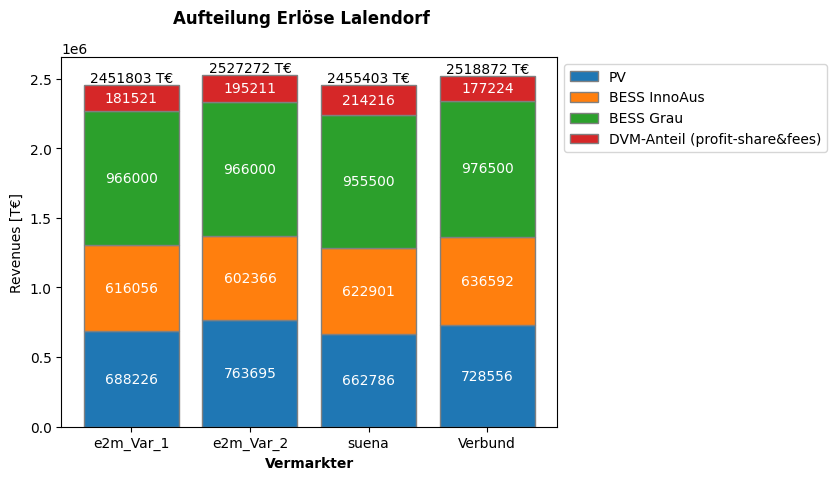

In [74]:
categories = ['e2m_Var_1', 'e2m_Var_2', 'suena', 'Verbund']
labels = ['PV', 'BESS InnoAus', 'BESS Grau', 'DVM-Anteil (profit-share&fees)']
values1 = [net_annual_pv_profit_e2m_var_1, net_annual_pv_profit_e2m_var_2, net_annual_pv_profit_suena, net_annual_pv_profit_verbund]  
values2 = [net_annual_bess_profit_e2m_var_1, net_annual_bess_profit_e2m_var_2, net_annual_bess_profit_suena, net_annual_bess_profit_verbund]   
values3 = [annual_bess_grey_profit * profit_share_e2m_grey, annual_bess_grey_profit * profit_share_e2m_grey, annual_bess_grey_profit * profit_share_suena, annual_bess_grey_profit * profit_share_verbund]   
values4 = [trading_profit_e2m_var_1_total, trading_profit_e2m_var_2_total, trading_profit_suena_total, trading_profit_verbund_total]   

fig, ax = plt.subplots()

# Set the positions for the bars
r1 = np.arange(len(categories))

# Create the stacked bar plot
ax.bar(r1, values1, edgecolor='grey', label=labels[0])
ax.bar(r1, values2, bottom=values1, edgecolor='grey', label=labels[1])
ax.bar(r1, values3, bottom=np.array(values1) + np.array(values2), edgecolor='grey', label=labels[2])
ax.bar(r1, values4, bottom=np.array(values1) + np.array(values2) + np.array(values3), edgecolor='grey', label=labels[3])
# ax.bar(r1, values5, bottom=np.array(values1) + np.array(values2) + np.array(values3) + np.array(values4), edgecolor='grey', label=labels[4])

# Calculate and display the sum of values for each category
sums = np.array(values1) + np.array(values2) + np.array(values3) + np.array(values4) # + np.array(values5)
for i, sum_value in enumerate(sums):
    ax.text(i, sum_value + 0.5, str(round(sum_value)) + " T€", ha='center', va='bottom')

# Label each segment of the stacked bars
for i in range(len(categories)):
    ax.text(i, values1[i] / 2, str(round(values1[i])), ha='center', va='center', color='white')
    ax.text(i, values1[i] + values2[i] / 2, str(round(values2[i])), ha='center', va='center', color='white')
    ax.text(i, values1[i] + values2[i] + values3[i] / 2, str(round(values3[i])), ha='center', va='center', color='white')
    ax.text(i, values1[i] + values2[i] + values3[i] + values4[i] / 2, str(round(values4[i])), ha='center', va='center', color='white')
    
# Adding labels
ax.set_xlabel('Vermarkter', fontweight='bold')
ax.set_xticks(r1)
ax.set_xticklabels(categories)
ax.set_ylabel('Revenues [T€]')
fig.suptitle('Aufteilung Erlöse Lalendorf', fontweight='bold')
# ax.set_title(year)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))